# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Pratyush457/week-1-/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Research question

Which pages show the strongest observed opportunity for CTR-focused human review when considering their search visibility and observed CTR?

The decision this work supports is **which content pages should a human review first**, rather than which pages should automatically be changed.

The analysis uses March 2026 search-performance signals and produces a ranked, directional decision-support queue. The goal is to prioritize limited review effort toward pages with meaningful visibility and relatively low observed CTR.

## Data

This capstone uses the FlyRank ML Internship dataset, using the March 2026 content daily performance data available for the analysis.

The main table used is `fact_content_daily_performance`. The analysis uses public-safe hashed identifiers and search-performance fields rather than client names, domains, URLs, private queries, or credentials.

The March 2026 window was used because the Week-4 baseline, Week-5 model, Week-6 validation, and Week-7 action playbook were built from the same decision-time data.

The main signals used were:

- GSC impressions
- GSC clicks
- GSC average position
- observed CTR, calculated from clicks and impressions

Rows without available GSC data or without positive impressions were excluded from the CTR-based ranking because CTR cannot be meaningfully calculated for those observations.

The future click outcome was used only for model validation and evaluation. Decision-time features were kept separate from the future outcome to reduce the risk of using information that would not have been available when making a recommendation.

No client names, domains, URLs, private queries, credentials, or raw exports are included in the public-facing analysis.

## Methodology

### Assumptions

The analysis treats observed search-performance signals as prioritization signals. It does not assume that a model score represents a causal effect or a guaranteed future improvement.

### Features

The model uses decision-time search signals:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `ctr_pct`

CTR is calculated from clicks divided by impressions for observations with positive impressions.

### Label

The prediction target is whether future clicks meet the positive-target condition defined in the modeling workflow. Future clicks are used only as the outcome for model training and validation, not as a decision-time feature.

### Baseline

The Week-4 baseline ranks pages using a simple opportunity score based on log-scaled impressions and lower observed CTR. This provides a transparent benchmark for evaluating whether the Random Forest adds useful ranking performance.

### Model

A Random Forest model was selected because it can capture nonlinear relationships between the search-performance features and the future-click target while still allowing feature importance to be inspected.

### Validation design

The Week-5 model used a time-aware split, with training observations occurring before the validation period. In Week 6, the model was additionally evaluated using a grouped-by-client split so that clients in validation were separated from clients used for training.

The grouped validation contained 36 training clients and 10 validation clients. This provides a stricter check of whether the ranking behavior transfers across client groups.

### Leakage checks

The future outcome was kept separate from the decision-time features. Features used for ranking were available at decision time, while future clicks were used only as the target for evaluation.

The Week-6 validation audit was used to check the model under a stricter grouped split and to identify whether the model's claims remained supported by the available evidence.

### Evaluation

The main ranking metric is Precision@50. The model is compared against the Week-4 baseline using the same evaluation concept, while the grouped validation is used as an additional robustness check.

## Results

### Model vs baseline

The Week-5 Random Forest was compared with the transparent Week-4 baseline using Precision@50.

| Approach | Precision@50 |
|---|---:|
| Week-4 baseline | 0.860 |
| Week-5 Random Forest | 1.000 |

On the Week-5 time-aware validation split, the Random Forest achieved a measured Precision@50 of 1.000 compared with 0.860 for the baseline.

### Stricter grouped validation

The Week-6 audit repeated the comparison using a grouped-by-client validation design.

| Validation | Approach | Precision@50 |
|---|---|---:|
| Week-5 time-aware split | Random Forest | 1.000 |
| Week-6 grouped-by-client split | Random Forest | 1.000 |
| Week-6 grouped-by-client split | Baseline | 1.000 |

Under the grouped validation used in Week 6, the Random Forest and baseline both measured 1.000 Precision@50. This means the stronger Week-5 result did not demonstrate an improvement over the baseline under this stricter validation setup.

### Feature interpretation

The Week-5 Random Forest feature importances were:

| Feature | Importance |
|---|---:|
| `gsc_impressions` | 0.760313 |
| `ctr_pct` | 0.097216 |
| `gsc_avg_position` | 0.073220 |
| `gsc_clicks` | 0.069251 |

`gsc_impressions` was the dominant measured feature importance in the fitted model. This should be interpreted as model behavior, not as evidence that impressions causally determine future clicks.

### Honest interpretation

The measured results show that the Random Forest outperformed the baseline on the Week-5 time-aware split, but the grouped-by-client audit did not show an advantage over the baseline. Therefore, the strongest defensible conclusion is that the model provides a useful ranking experiment and decision-support signal, rather than evidence of a generally superior production model.

## Limitations and honest framing

This analysis has several important limitations.

First, the model was trained and evaluated on the available FlyRank internship dataset and should not automatically be assumed to generalize to other datasets, time periods, clients, or content populations.

Second, the Week-5 Random Forest measured higher Precision@50 than the baseline on the time-aware split, but the Week-6 grouped-by-client validation showed both the baseline and Random Forest at 1.000 Precision@50. The grouped result therefore does not establish that the Random Forest is consistently better than the baseline.

Third, the model uses search-performance signals such as impressions, clicks, CTR, and average position. These signals describe observed performance but do not capture page intent, content quality, seasonality, business context, brand requirements, or the specific reason a user did or did not click.

Fourth, feature importance describes which features the fitted model relied on most strongly. It does not establish causality. In particular, the high importance of impressions should not be interpreted as proof that increasing impressions will cause more clicks.

Finally, the ranked recommendations are decision-support outputs. They identify pages for human review; they do not automatically determine what content or metadata changes should be made.

The results should therefore be described as **observed, measured, directional, and decision-support**, rather than causal or guaranteed.

## Ranked recommendations

The validated action playbook prioritizes pages for human review rather than prescribing automatic changes.

### Priority 1 — Review high-visibility, low-CTR pages

Pages with meaningful search visibility and relatively low observed CTR should be reviewed first.

**Reason code:** `CTR_OPPORTUNITY`  
**Action:** `REVIEW_CTR`

The purpose of the review is to understand whether the observed CTR is appropriate for the page's search intent and whether a metadata or content review is justified.

### Priority 2 — Review before making changes

No content or metadata change should be made directly from the model score.

**Reason code:** `REVIEW_BEFORE_CHANGE`  
**Action:** `HUMAN_REVIEW`

A reviewer should consider search intent, content quality, business context, seasonality, and recent performance before deciding whether any change is appropriate.

### Action playbook

| Priority | Signal / archetype | Action | Reason code |
|---|---|---|---|
| 1 | High visibility + low CTR | `REVIEW_CTR` | `CTR_OPPORTUNITY` |
| 2 | Moderate visibility + low CTR | `REVIEW_CTR` | `CTR_OPPORTUNITY` |
| 3 | Lower visibility / weaker signal | `HUMAN_REVIEW` | `REVIEW_BEFORE_CHANGE` |

### What should not be automated

The following decisions should remain human-reviewed:

- changing page content solely because of the model score;
- changing titles or metadata without checking search intent;
- deleting, merging, or pruning pages automatically;
- treating the score as a probability of improvement;
- treating the ranking as evidence of a causal Google ranking signal.

The queue is best used to reduce manual triage effort and identify where review may be most useful.

### Monitoring and refresh

The queue should be regenerated when the underlying search-performance data changes materially. Performance distributions, Precision@50, feature behavior, and the usefulness of the ranked actions should be reviewed over time.

A material decline in evaluation performance or a meaningful change in the underlying data distribution should trigger a model review or retraining assessment.

Older content may also warrant periodic review when its observed performance changes, but age alone should not trigger an automatic refresh.

## Artifacts the paper embeds

The paper will embed a small set of artifacts that make the analysis easier to inspect:

1. **Model vs baseline table** — Precision@50 on the time-aware split and the stricter grouped-by-client validation.
2. **Feature importance chart** — the measured feature importance of the four model inputs.
3. **Ranked action summary** — the top-ranked review opportunities generated by the validated playbook.
4. **Validation comparison** — before/after comparison showing how the model behaved under the stricter grouped validation.

These artifacts are intended to make the measured results and recommendations transparent and reproducible. They are descriptive and decision-support outputs, not evidence of causal effects.

MODEL VS BASELINE


,Approach,Precision@50
0,Week-4 baseline,0.86
1,Week-5 Random Forest,1.00
2,Week-6 grouped baseline,1.00
3,Week-6 grouped Random Forest,1.00


FEATURE IMPORTANCE


,Feature,Importance
0,gsc_impressions,0.760313
3,ctr_pct,0.097216
2,gsc_avg_position,0.073220
1,gsc_clicks,0.069251


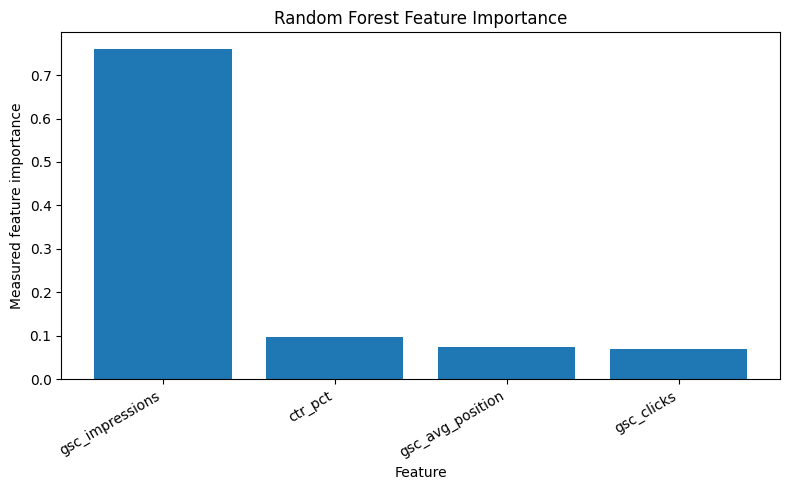

VALIDATION COMPARISON


,Validation,Baseline Precision@50,Random Forest Precision@50
0,Week-5 time-aware,0.86,1.0
1,Week-6 grouped-by-client,1.00,1.0


In [1]:
# Section 7: Paper artifacts

import matplotlib.pyplot as plt
import pandas as pd

# Model vs baseline results
results = pd.DataFrame({
    "Approach": [
        "Week-4 baseline",
        "Week-5 Random Forest",
        "Week-6 grouped baseline",
        "Week-6 grouped Random Forest"
    ],
    "Precision@50": [
        0.860,
        1.000,
        1.000,
        1.000
    ]
})

print("MODEL VS BASELINE")
display(results)

# Feature importance artifact
feature_importance = pd.DataFrame({
    "Feature": [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "ctr_pct"
    ],
    "Importance": [
        0.760313,
        0.069251,
        0.073220,
        0.097216
    ]
}).sort_values("Importance", ascending=False)

print("FEATURE IMPORTANCE")
display(feature_importance)

plt.figure(figsize=(8, 5))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.ylabel("Measured feature importance")
plt.xlabel("Feature")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Validation comparison artifact
validation_summary = pd.DataFrame({
    "Validation": [
        "Week-5 time-aware",
        "Week-6 grouped-by-client"
    ],
    "Baseline Precision@50": [
        0.860,
        1.000
    ],
    "Random Forest Precision@50": [
        1.000,
        1.000
    ]
})

print("VALIDATION COMPARISON")
display(validation_summary)

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit my repo URL on the card. Done.
- [x] My deployed paper has all 9 sections — including the Abstract at the top and Acknowledgments & data credit at the bottom.
- [x] ML-12 done in this notebook's closing cells: 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.

## ML-12 — 5-minute demo outline

### 0:00–0:45 — Problem
Explain the goal: prioritize content pages for human review using observed search-performance signals.

### 0:45–1:30 — Data
Describe the March 2026 FlyRank internship dataset and the decision-time features used.

### 1:30–2:30 — Modeling
Show the Week-4 baseline, Week-5 Random Forest, and the time-aware validation design.

### 2:30–3:30 — Validation
Explain the Week-6 grouped-by-client validation and why it provides a stricter check.

### 3:30–4:30 — Recommendations
Show the ranked action queue and explain the `CTR_OPPORTUNITY` → `REVIEW_CTR` workflow.

### 4:30–5:00 — Honest takeaway
The model produced a stronger measured result on the time-aware split, but the grouped validation did not show an advantage over the baseline. The output is therefore best presented as directional decision-support rather than a production automation system.

## Social-post cut

Built an ML capstone on the FlyRank internship dataset to prioritize content pages for human review using search-performance signals.

I compared a transparent baseline with a Random Forest, then stress-tested the result using grouped-by-client validation.

The biggest lesson was not just getting a higher score — it was learning to validate the claim, check for leakage, and turn model output into an honest action playbook.

The final output is directional decision-support, not an automatic content-change system.

## Employer-facing summary

I built and validated a machine-learning workflow that ranks content pages for human review using search-performance signals. I compared a transparent baseline with a Random Forest, evaluated the model using time-aware and grouped-by-client validation, and performed leakage and error checks. The final deliverable turns the validated model output into an explainable, human-reviewed action playbook rather than claiming unsupported causal or production-level performance.